# STIPS Tutorial

***

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.1". 

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.

## Introduction

**STIPS**, or the Space Telescope Imaging Product Simulator, is a tool developed by STScI for simulating observations of astronomical scenes with the Roman Wide Field Instrument (WFI). Detailed documentation of the tool is available on the [RDox pages](https://roman-docs.stsci.edu/simulation-tools-handbook-home/stips-space-telescope-imaging-product-simulator).

STIPS can generate images of the entire WFI array, which consists of 18 detectors, also called Sensor Chip Assemblies (SCAs). For more information on the WFI detectors and focal plane array please see the [RDox documentation](https://roman-docs.stsci.edu/simulation-tools/additional-simulation-tools/stips-space-telescope-imaging-product-simulator). STIPS depends on the [Pandeia Exposure time calculator](https://roman-docs.stsci.edu/simulation-tools-handbook-home/roman-wfi-exposure-time-calculator/pandeia-for-roman) and the [STPSF point spread function (PSF) generator](https://roman-docs.stsci.edu/simulation-tools-handbook-home/stpsf-for-roman) to create these simulations. Tutorial notebooks for both [Pandeia](../pandeia/pandeia.ipynb) and [STPSF](../stpsf/stpsf.ipynb) are also available. Users can choose to simulate between 1 and 18 SCAs in any of the WFI imaging filters, insert any number of point or extended sources, and specify a sky background estimate. STIPS will scale input fluxes to observed values, retrieve appropriate PSFs (interpolated to the positions of the sources), and add in additional noise terms.

As described in the [Caveats to Using STIPS for Roman](https://roman-docs.stsci.edu/simulation-tools-handbook-home/stips-space-telescope-imaging-product-simulator/caveats-of-using-stips-for-roman), neither pixel saturation nor non-linearity residuals are currently supported.

This notebook is a starter guide to simulating and manipulating scenes with STIPS.

## Reference Data

The cell below will check to ensure ancillary reference files for `stips` and `pandeia` packages are installed. If not, it will download the ancillary reference files and install them under your home directory (i.e., `${HOME}/refdata/`).

### Local Run Settings

If you want to run the notebook in your local machine, refer to the information in [local installation](../../markdown/local-run.md) instructions before proceeding with the notebook. The instructions provide important information about setting up your environment, installing dependencies, and adding to your working directory scripts to help with the reference data installation.

Depending on which (if any) reference data are missing, this cell may take several minutes to execute.

### On the Roman Research Nexus

If you are working on the Nexus, then the ancillary reference data are pre-installed and this cell will execute instantly.

In [1]:
import os
import sys
import importlib.util

import notebook_data_dependencies as ndd

# Download reference data (if necessary)
result = ndd.install_files(packages=['stips', 'stpsf', 'pandeia_data', 'pandeia_psf', 'synphot'])
ndd.setup_env(result)

Did not find pandeia_data data in environment, setting it up...
	Found 1 data URL(s) to download and install...
	Working on file 1 out of 1


	Update environment variable with the following:
		export pandeia_refdata='/home/runner/refdata/pandeia_data-2026.1-roman'
Did not find pandeia_psf data in environment, setting it up...
	Found 1 data URL(s) to download and install...
	Working on file 1 out of 1


	Update environment variable with the following:
		export PSF_DIR='/home/runner/refdata/pandeia_psfs-2026.1-roman'
Did not find stpsf data in environment, setting it up...
	Found 1 data URL(s) to download and install...
	Working on file 1 out of 1


	Update environment variable with the following:
		export STPSF_PATH='/home/runner/refdata/stpsf-data'
Did not find stips data in environment, setting it up...
	Found 1 data URL(s) to download and install...
	Working on file 1 out of 1


	Update environment variable with the following:
		export stips_data='/home/runner/refdata/stips_data'
Did not find synphot data in environment, setting it up...
	Found 9 data URL(s) to download and install...
	Working on file 1 out of 9


...

	Working on file 6 out of 9


	Working on file 7 out of 9


	Working on file 8 out of 9


	Working on file 9 out of 9


	Update environment variable with the following:
		export PYSYN_CDBS='/home/runner/refdata/grp/redcat/trds/'
Reference data paths set to:
	pandeia_refdata = /home/runner/refdata/pandeia_data-2026.1-roman
	PSF_DIR = /home/runner/refdata/pandeia_psfs-2026.1-roman
	STPSF_PATH = /home/runner/refdata/stpsf-data
	stips_data = /home/runner/refdata/stips_data
	PYSYN_CDBS = /home/runner/refdata/grp/redcat/trds/
	CRDS_SERVER_URL = https://roman-crds.stsci.edu (pre-set, not overwritten)
	CRDS_CONTEXT = roman-edit (pre-set, not overwritten)
	CRDS_OBSERVATORY = roman
	CRDS_PATH = /home/runner/crds_cache (pre-set, not overwritten)


## Imports

Besides the STIPS-related imports, the `matplotlib` imports will help visualize simulated images and `astropy.io.fits` will help write a FITS table on the fly.

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import stips
import yaml

from astropy.io import fits
from stips.astro_image import AstroImage
from stips.observation_module import ObservationModule
from stips.scene_module import SceneModule

### Environment report

To verify the existing STIPS installation alongside its associated data files and dependencies, run the cell below. (Find the current software requirements [in the STIPS documentation](https://stips.readthedocs.io/en/latest/installation.html#stips-requirements).)

In [3]:
print(stips.__env__report__)

STIPS Version 2.3.1 with Data Version 1.0.10 at /home/runner/refdata/stips_data.
STIPS Grid Generated with STIPS Version 1.1.0.
Pandeia Version 2026.2 with Data Version 2026.1 at /home/runner/refdata/pandeia_data-2026.1-roman and PSF Version 2026.1 at /home/runner/refdata/pandeia_psfs-2026.1-roman.
stpsf Version 2.2.0 with Data Version 2.2.0 at /home/runner/refdata/stpsf-data.



***

## Examples

### Basic STIPS Usage

This tutorial builds on the concepts introduced in the [STIPS Overview](https://roman-docs.stsci.edu/simulation-tools-handbook-home/stips-space-telescope-imaging-product-simulator/overview-of-stips) article and is designed to walk through the phases of using STIPS at the most introductory level: creating a small scene, designing an observation, and generating a simulated image.

At its most fundamental level, STIPS takes a dictionary of observation and instrument parameters and a source catalog in order to return a simulated image. The source catalog can be either a user-defined input catalog in FITS format or it can be simulated using the STIPS `SceneModule` class (see below).

In this example, we start by specifying an **observation dictionary** for an image taken with the F129 filter, using the Detector 1 (WFI01), and with an exposure time of 300 seconds.

**Note:** We first need to update the path to the PSF cache using a YAML configuration file. A patch to fix the setting of this path in STIPS module calls will be released in the near future.

In [4]:
fix = {'psf_cache_location': os.environ["HOME"]}
with open('./stips_config.yaml', 'w') as file:
    yaml.dump(fix, file)

Now we set up the observation dictionary:

In [5]:
obs = {'instrument': 'WFI', 'filters': ['F129'], 'detectors': 1,
       'background': 'pandeia', 'observations_id': 42, 'exptime': 300,
       'offsets': [{'offset_id': 1, 'offset_centre': False, 'offset_ra': 0.0,
                    'offset_dec': 0.0, 'offset_pa': 0.0}]
       }

Then we feed the dictionary to an instance of the `ObservationModule` class, while also specifying the central coordinates (90 degrees right ascension and 30 degrees declination) and position angle (0 degrees) as keyword arguments.

In [6]:
obm = ObservationModule(obs, ra=90, dec=30, pa=0, seed=42, cores=6)

2026-09-06 02:42:48,339 INFO: Got offsets as [{'offset_id': 1, 'offset_centre': False, 'offset_ra': 0.0, 'offset_dec': 0.0, 'offset_pa': 0.0}]


2026-09-06 02:42:48,369 INFO: Adding observation with filter F129 and offset (0.0,0.0,0.0)


2026-09-06 02:42:48,369 INFO: Added 1 observations


2026-09-06 02:42:48,610 INFO: WFI with 1 detectors. Central offset (np.float64(2.065830864204697e-13), np.float64(-8.945310041616143e-14), 0)


#### Create a Simple Astronomical Scene

The other requirement is an input source catalog. In this case, we generate and input a user-defined catalog. STIPS accepts [several types of tables and catalogs](https://stips.readthedocs.io/en/latest/using_stips/catalogue_formats.html#stips-table-formats) in either the IPAC text or FITS BinTable format. This example uses a Mixed Catalog, which requires the following columns:

* `id`: Object ID
* `ra`: Right ascension (RA), in degrees
* `dec`: Declination (DEC), in degrees
* `flux`: Flux, in `units` (defined below)
* `type`: Approximation used to profile a source. Options are `'sersic'` (for extended sources) or `point`
* `n`: Sersic profile index
* `phi`: Position angle of the Sersic profle's major axis, in degrees
* `ratio`: Ratio of the Sersic profile's major and minor axes
  * Since `n`, `phi`, `ratio` only apply to extended sources, they are ignored in rows where `type` is set to `'point'`.
* `notes`: Optional per-source comments
* `units`: One of `‘p’` for photons/s, `‘e’` for electrons/s, `‘j’` for Jansky, or `‘c’` for counts/s

Below, we create a catalog containing two sources located near the central coordinates specified in the `ObservationModule`.

In [7]:
cols = [
    fits.Column(name='id', array=[1, 2], format='K'),
    fits.Column(name='ra', array=[90.02, 90.03], format='D'),
    fits.Column(name='dec', array=[29.98, 29.97], format='D'),
    fits.Column(name='flux', array=[0.00023, 0.0004], format='D'),
    fits.Column(name='type', array=['point', 'point'], format='8A'),
    fits.Column(name='n', array=[0, 0], format='D'),
    fits.Column(name='re', array=[0, 0], format='D'),
    fits.Column(name='phi', array=[0, 0], format='D'),
    fits.Column(name='ratio', array=[0, 0], format='D'),
    fits.Column(name='notes', array=['', ''], format='8A'),
    fits.Column(name='units', array=['j', 'j'], format='8A')
]

Next, we save the columns as a FITS table in the BinTable format and assign header keys that specify the filter and catalog type:

In [8]:
hdut = fits.BinTableHDU.from_columns(cols)
hdut.header['TYPE'] = 'mixed'
hdut.header['FILTER'] = 'F129'

And we save the catalog locally:

In [9]:
cat_file = 'catalog.fits'
hdut.writeto(cat_file, overwrite=True)

#### Simulate an Image

With the observation module and source catalog in tow, STIPS can take over the image simulation process. First, we trigger the initialization of a new observation:

In [10]:
obm.nextObservation()

2026-09-06 02:42:48,639 INFO: Initializing Observation 0 of 1


2026-09-06 02:42:48,640 INFO: Observation Filter is F129


2026-09-06 02:42:48,641 INFO: Observation (RA,DEC) = (90.0,30.0) with PA=0.0


2026-09-06 02:42:48,641 INFO: Resetting


2026-09-06 02:42:48,892 INFO: Returning background 0.10970060309254233 for 'pandeia'


...

2026-09-06 02:42:48,933 INFO: WFI01: (RA, DEC, PA) := (90.0, 30.0, 0.0), detected as (90.0, 30.0, 0.0)


2026-09-06 02:42:48,933 INFO: Detector WFI01 created


2026-09-06 02:42:48,933 INFO: Reset Instrument


Creating pandeia instrument roman.wfi.imaging


0

Next, we simulate an image containing the sources from the catalog we created earlier. Then, we add error residuals to the image:

In [11]:
cat_name = obm.addCatalogue(cat_file)

2026-09-06 02:42:48,940 INFO: Running catalogue catalog.fits


2026-09-06 02:42:48,941 INFO: Adding catalogue catalog.fits


2026-09-06 02:42:48,948 INFO: Converting mixed catalogue


2026-09-06 02:42:48,948 INFO: Preparing output table


2026-09-06 02:42:48,962 INFO: Converting chunk 2


...

    Position 9/9 centroid: (np.float64(87.63467976133113), np.float64(88.31165394312333))
  Saving file: /home/runner/psf_cache/psf_WFI_2.3.1_F129_wfi01.fits


2026-09-06 02:43:33,804 INFO: Adding point source 1 to AstroImage 2631.9672457028046,1410.503966182148


2026-09-06 02:43:33,816 INFO: Adding point source 2 to AstroImage 2915.5365753799083,1083.2929624680437


2026-09-06 02:43:33,837 INFO: Added catalogue catalog_42_conv_F129.fits to AstroImage WFI01


2026-09-06 02:43:33,838 INFO: Finished catalogue catalog.fits


In [12]:
obm.addError()

2026-09-06 02:43:33,842 INFO: Adding Error


2026-09-06 02:43:33,843 INFO: Adding residual error


2026-09-06 02:43:33,871 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:43:34,106 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:43:34,107 INFO: Created AstroImage WFI01 and imported data from FITS file err_flat_wfi.fits


...

2026-09-06 02:43:35,678 INFO: Adding Dark residual with mean 0.20807769894599915 and standard deviation 1.1006208658218384


2026-09-06 02:43:35,678 INFO: Adding cosmic ray residual


2026-09-06 02:43:36,472 INFO: Adding Cosmic Ray residual with mean 0.0847659632563591 and standard deviation 1.9229004383087158


2026-09-06 02:43:36,476 INFO: Finished adding error


2026-09-06 02:43:36,478 INFO: Finished Adding Error


We finish by saving the outputs to a FITS file. The `finalize()` method of the `ObservationModule` object can also return a full field of view mosaic and a list of the simulation's initial parameters.

In [13]:
fits_file_1, _, params_1 = obm.finalize(mosaic=False)
print(f"Output FITS file is {fits_file_1}")

2026-09-06 02:43:36,482 INFO: Converting to FITS file


2026-09-06 02:43:36,483 INFO: Converting detector WFI01 to FITS extension


2026-09-06 02:43:36,483 INFO: Creating Extension HDU from AstroImage WFI01


2026-09-06 02:43:36,486 INFO: Created Extension HDU from AstroImage WFI01


2026-09-06 02:43:36,510 INFO: Created FITS file /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/sim_42_0.fits


Output FITS file is /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/sim_42_0.fits


In [14]:
for prm in params_1:
    print(prm)

Instrument: WFI
Filters: F129
Pixel Scale: (0.110,0.110) arcsec/pix
Pivot Wavelength: 1.290 um
Background Type: Pandeia background rate
Exposure Time: 300.0s
Input Unit: counts/s
Added Flatfield Residual: True
Added Dark Current Residual: True
Added Cosmic Ray Residual: True
Added Readnoise: True
Added Poisson Noise: True
Detector X size: 4088
Detector Y size: 4088
Random Seed: 42


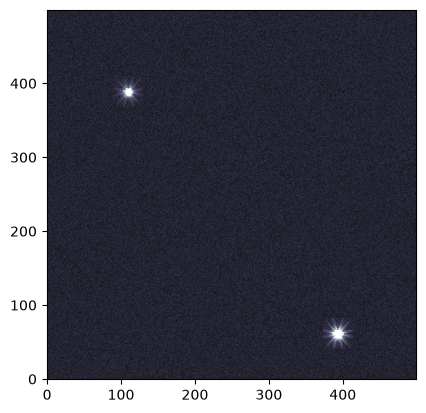

In [15]:
img_1 = fits.getdata(fits_file_1)[1000:1500, 2500:3000]

plt.imshow(img_1, vmax=1.5, origin='lower', cmap='bone')

### Generate Scenes Using STIPS Built-In Functions

STIPS can simulate scenes by importing pre-existing catalogs (as in the first example) or by using built-in functionality that generates collections of stars or galaxies based on user-specified parameters. Below, we will use the STIPS `SceneModule` to generate a stellar population and a galactic population.

First, we specify a set of parameters that will be used in both scenes (RA, DEC, ID) and initialize two `SceneModule` instances, one for the stellar population and one for the galaxy population:

In [16]:
obs_prefix_1 = 'notebook_example1'
obs_ra = 150.0
obs_dec = -2.5

scm_stellar = SceneModule(out_prefix=obs_prefix_1, ra=obs_ra, dec=obs_dec)
scm_galactic = SceneModule(out_prefix=obs_prefix_1, ra=obs_ra, dec=obs_dec)

Log level: INFO
Log level: INFO


#### Create a Stellar Population

Now we create a dictionary containing the parameters of the desired stellar population to pass to the `SceneModule` instance's `CreatePopulation()` method. The following parameters are needed to define a stellar population:

- Number of point sources
- Upper and lower limit of the age of the stars (in years)
- Upper and lower limit of the metallicity of the stars
- Initial Mass Function
- Binary fraction
- Clustering (True/False)
- Distribution type (Uniform, Inverse power-law)
- Total radius of the population
- Distance from the population
- Offset RA and DEC from the center of the scene being created

A full accounting of each dictionary entry's meaning can be found in the docstring of the `CreatePopulation()` method:

In [17]:
scm_stellar.CreatePopulation?

In [18]:
stellar_parameters = {'n_stars': 100, 'age_low': 7.5e12, 'age_high': 7.5e12,
                      'z_low': -2.0, 'z_high': -2.0, 'imf': 'salpeter',
                      'alpha': -2.35, 'binary_fraction': 0.1,
                      'distribution': 'invpow', 'clustered': True,
                      'radius': 100.0, 'radius_units': 'pc',
                      'distance_low': 20.0, 'distance_high': 20.0,
                      'offset_ra': 0.0, 'offset_dec': 0.0
                      }

We pass the dictionary to the stellar `SceneModule` instance's `CreatePopulation()` method. Running the method will save the newly-generated population locally.

In [19]:
stellar_cat_file = scm_stellar.CreatePopulation(stellar_parameters)
print(f"Stellar population saved to file {stellar_cat_file}")

2026-09-06 02:43:36,796 INFO: Creating catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000.fits


2026-09-06 02:43:36,796 INFO: Creating age and metallicity numbers


2026-09-06 02:43:36,796 INFO: Created age and metallicity numbers


2026-09-06 02:43:36,797 INFO: Creating stars


2026-09-06 02:43:36,797 INFO: Age 1.35e+10


...

2026-09-06 02:43:36,798 INFO: Creating 100 stars


2026-09-06 02:43:37,147 INFO: Creating 100 objects, max radius 100.0, function invpow, scale 2.8


2026-09-06 02:43:37,200 INFO: Chunk 1: 112 stars


2026-09-06 02:43:37,213 INFO: Done creating catalogue


Stellar population saved to file /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000.fits


#### Create a Galactic Population

Repeat the population generation process, now by creating a dictionary containing parameters of a desired _galactic_ population. The following paramters are needed to define a galaxy population:

- Number of galaxies
- Upper and lower limit of the redshift
- Upper and lower limit of the galactic radii
- Range of V-band surface brightness magnitudes
- Clustering (True/False)
- Distribution type (Uniform, Inverse power-law)
- Radius of the distribution
- Offset RA and DEC from the center of the scene being created

A full accounting of each dictionary entry's meaning can be found in the docstring of the `CreateGalaxies()` method:

In [20]:
scm_galactic.CreateGalaxies?

We pass the dictionary to the galaxy `SceneModule` instance's `CreateGalaxies()` method, and save the result locally:

In [21]:
galaxy_parameters = {'n_gals': 10, 'z_low': 0.0, 'z_high': 0.2,
                     'rad_low': 0.01, 'rad_high': 2.0,
                     'sb_v_low': 30.0, 'sb_v_high': 25.0,
                     'distribution': 'uniform', 'clustered': False,
                     'radius': 200.0, 'radius_units': 'arcsec',
                     'offset_ra': 0.0, 'offset_dec': 0.0
                     }

In [22]:
galaxy_cat_file = scm_galactic.CreateGalaxies(galaxy_parameters)
print(f"Galaxy population saved to file {galaxy_cat_file}")

2026-09-06 02:43:37,227 INFO: Creating catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000.fits


2026-09-06 02:43:37,227 INFO: Wrote preamble


2026-09-06 02:43:37,227 INFO: Parameters are: {'n_gals': 10, 'z_low': 0.0, 'z_high': 0.2, 'rad_low': 0.01, 'rad_high': 2.0, 'sb_v_low': 30.0, 'sb_v_high': 25.0, 'distribution': 'uniform', 'clustered': False, 'radius': 200.0, 'radius_units': 'arcsec', 'offset_ra': 0.0, 'offset_dec': 0.0}


2026-09-06 02:43:37,229 INFO: Making Co-ordinates


2026-09-06 02:43:37,229 INFO: Creating 10 objects, max radius 200.0, function uniform, scale 2.8


2026-09-06 02:43:37,230 INFO: Converting Co-ordinates into RA,DEC


2026-09-06 02:43:37,241 INFO: Done creating catalogue


Galaxy population saved to file /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000.fits


#### Set up an Observation (First Pointing)

Once we've created a scene, we can use STIPS to simulate as many exposures of it in as many orientations as we'd like. In STIPS, a single telescope pointing is called an _offset_, and a collection of exposures is an _observation_.

We start this subsection by creating a single _offset_ that is dithered by 2 degrees in right ascension and rotated by 0.5 degrees in position angle from the center of the scene.

In [23]:
offset_1 = {'offset_id': 1, 'offset_centre': False,
            # True would center each detector on the same on-sky point
            'offset_ra': 2.0, 'offset_dec': 0.0, 'offset_pa': 0.5
            }

The offset information is contained within an _observation_ that is taken with the F129 filter, uses detectors WFI01 through WFI03, and has an exposure time of 1500 seconds. We also apply distortion and specify a sky background of 0.24 counts/s/pixel.

In [24]:
observation_parameters_1 = {'instrument': 'WFI', 'filters': ['F129'],
                            'detectors': 3, 'distortion': True,
                            'background': 0.24, 'observations_id': 1,
                            'exptime': 1500, 'offsets': [offset_1]
                            }

STIPS can also apply various types of error residuals to the observation. Here, we only include residuals from flat-fields and the dark current.

In [25]:
residuals_1 = {'residual_flat': True, 'residual_dark': True,
               'residual_cosmic': False, 'residual_poisson': False,
               'residual_readnoise': False
               }

Next, we feed the observation dictionary to an instance of the `ObservationModule` class, alongside the observation ID, right ascension, and declination specified earlier in this example.

In [26]:
obm_1 = ObservationModule(observation_parameters_1, residual=residuals_1,
                          out_prefix=obs_prefix_1, ra=obs_ra, dec=obs_dec)

2026-09-06 02:43:37,260 INFO: Got offsets as [{'offset_id': 1, 'offset_centre': False, 'offset_ra': 2.0, 'offset_dec': 0.0, 'offset_pa': 0.5}]


2026-09-06 02:43:37,279 INFO: Adding observation with filter F129 and offset (2.0,0.0,0.5)


2026-09-06 02:43:37,280 INFO: Added 1 observations


2026-09-06 02:43:37,458 INFO: WFI with 3 detectors. Central offset (np.float64(1.7907664211548176e-13), np.float64(-8.945310041616143e-14), 0)


We call the `ObservationModule` object's `nextObservation()` method to move to the first offset/filter combination (`offset_1` and F129) contained in the object.

In [27]:
obm_1.nextObservation()

2026-09-06 02:43:37,463 INFO: Initializing Observation 0 of 1


2026-09-06 02:43:37,464 INFO: Observation Filter is F129


2026-09-06 02:43:37,464 INFO: Observation (RA,DEC) = (150.00055555555556,-2.5) with PA=0.5


2026-09-06 02:43:37,464 INFO: Resetting


2026-09-06 02:43:37,465 INFO: Returning background 0.24.


...

2026-09-06 02:43:37,529 INFO: WFI03: (RA, DEC, PA) := (150.00076976694686, -2.777285221181246, 0.5), detected as (150.00076976694686, -2.777285221181246, 0.5000000000001229)


2026-09-06 02:43:37,529 INFO: Detector WFI03 created


2026-09-06 02:43:37,530 INFO: Reset Instrument


Creating pandeia instrument roman.wfi.imaging


0

Now that the observation is fully set up, we add the stellar and galactic populations to it. (Please note that each population may take about a minute to load.)

In [28]:
output_stellar_catalogs_1 = obm_1.addCatalogue(stellar_cat_file)
output_galaxy_catalogs_1 = obm_1.addCatalogue(galaxy_cat_file)
print(f"Output Catalogs are {output_stellar_catalogs_1} and "
      f"{output_galaxy_catalogs_1}.")

2026-09-06 02:43:37,535 INFO: Running catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000.fits


2026-09-06 02:43:37,536 INFO: Adding catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000.fits


2026-09-06 02:43:37,546 INFO: Converting phoenix catalogue


2026-09-06 02:43:37,547 INFO: Preparing output table


2026-09-06 02:43:37,565 INFO: Converting chunk 2


...

2026-09-06 02:45:11,108 INFO: Determining pixel co-ordinates


2026-09-06 02:45:11,108 INFO: Keeping 0 items


2026-09-06 02:45:11,110 INFO: Added catalogue notebook_example1_gals_000_01_conv_F129.fits to AstroImage WFI03


2026-09-06 02:45:11,110 INFO: Finished catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000.fits



Step 9 duration in WFI01 with fast_galaxy=False and convolve_galaxy=True: 5.4931 seconds, Running total: 50.6522 seconds
Output Catalogs are ['/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129_observed_WFI01.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129_observed_WFI02.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129_observed_WFI03.fits'] and ['/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000_01_conv_F129.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000_01_conv_F129_observed_WFI01.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000_01_conv_F1

In [29]:
obm_1.addError()

2026-09-06 02:45:11,114 INFO: Adding Error


2026-09-06 02:45:11,115 INFO: Adding residual error


2026-09-06 02:45:11,144 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:45:11,376 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:45:11,377 INFO: Created AstroImage WFI01 and imported data from FITS file err_flat_wfi.fits


...

2026-09-06 02:45:11,912 INFO: Adding Flatfield residual with mean 1.0097910165786743 and standard deviation 0.0006765797734260559


2026-09-06 02:45:11,913 INFO: Adding dark residual


2026-09-06 02:45:11,947 INFO: Adding Dark residual with mean 1.0403887033462524 and standard deviation 5.5031046867370605


2026-09-06 02:45:11,951 INFO: Finished adding error


2026-09-06 02:45:11,952 INFO: Finished Adding Error


As before, finish by saving the simulated image to a FITS file.

In [30]:
fits_file_1, _, params_1 = obm_1.finalize(mosaic=False)
print(f"Output FITS file is {fits_file_1}")

2026-09-06 02:45:11,957 INFO: Converting to FITS file


2026-09-06 02:45:11,958 INFO: Converting detector WFI01 to FITS extension


2026-09-06 02:45:11,958 INFO: Creating Extension HDU from AstroImage WFI01


2026-09-06 02:45:11,961 INFO: Created Extension HDU from AstroImage WFI01


2026-09-06 02:45:11,962 INFO: Converting detector WFI02 to FITS extension


...

2026-09-06 02:45:11,964 INFO: Converting detector WFI03 to FITS extension


2026-09-06 02:45:11,965 INFO: Creating Extension HDU from AstroImage WFI03


2026-09-06 02:45:11,966 INFO: Created Extension HDU from AstroImage WFI03


2026-09-06 02:45:12,038 INFO: Created FITS file /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_1_0.fits


Output FITS file is /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_1_0.fits


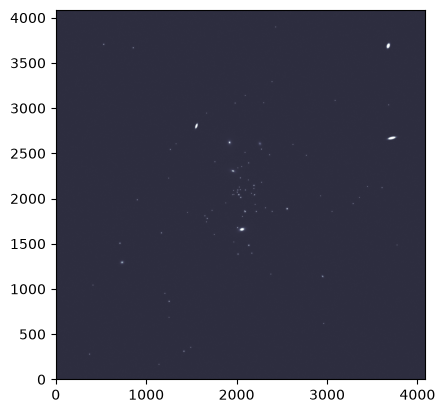

In [31]:
img_1 = fits.getdata(fits_file_1, ext=1)

plt.imshow(img_1, vmin=0.15, vmax=0.6, origin='lower', cmap='bone')

#### Modify an Observation (by Adding a Second Pointing)

To observe the same scene under different conditions, we make a new `ObservationModule` object that takes updated versions of the input observation parameter and residual dictionaries. The collection of resulting `ObservationModule` objects can be thought of as a dithered set of observations.

For the second observation, we assume an offset of 10 degrees in right ascension and rotated by 27 degrees in position angle from the center of the scene.

In [32]:
offset_2 = {'offset_id': 1, 'offset_centre': False,
            # True centers each detector on same point
            'offset_ra': 10.0, 'offset_dec': 0.0, 'offset_pa': 27
            }

The second observation is identical to the first (F129 filter, detectors WFI01 through WFI03, exposure time of 1500 seconds, distortion, and a sky background of 0.24 counts/s/pixel) with the exception of the offset parameters.

In [33]:
observation_parameters_2 = {'instrument': 'WFI', 'filters': ['F129'],
                            'detectors': 3, 'distortion': True,
                            'background': 0.24, 'observations_id': 1,
                            'exptime': 1500, 'offsets': [offset_2]
                            }

This time, we include residuals from the flat-field and read noise.

In [34]:
residuals_2 = {'residual_flat': True, 'residual_dark': False,
               'residual_cosmic': False, 'residual_poisson': False,
               'residual_readnoise': True
               }

We create the new `ObservationModule` object and initialize it for a simulation.

In [35]:
obs_prefix_2 = 'notebook_example2'
obm_2 = ObservationModule(observation_parameters_2, residuals=residuals_2,
                          out_prefix=obs_prefix_2, ra=obs_ra, dec=obs_dec)

2026-09-06 02:45:13,860 INFO: Got offsets as [{'offset_id': 1, 'offset_centre': False, 'offset_ra': 10.0, 'offset_dec': 0.0, 'offset_pa': 27}]


2026-09-06 02:45:13,890 INFO: Adding observation with filter F129 and offset (10.0,0.0,27)


2026-09-06 02:45:13,891 INFO: Added 1 observations


2026-09-06 02:45:14,065 INFO: WFI with 3 detectors. Central offset (np.float64(1.7907664211548176e-13), np.float64(-8.945310041616143e-14), 0)


In [36]:
obm_2.nextObservation()

2026-09-06 02:45:14,070 INFO: Initializing Observation 0 of 1


2026-09-06 02:45:14,071 INFO: Observation Filter is F129


2026-09-06 02:45:14,071 INFO: Observation (RA,DEC) = (150.00277777777777,-2.5) with PA=27.0


2026-09-06 02:45:14,071 INFO: Resetting


2026-09-06 02:45:14,072 INFO: Returning background 0.24.


...

2026-09-06 02:45:14,134 INFO: WFI03: (RA, DEC, PA) := (150.00299198916906, -2.777285221181246, 27.0), detected as (150.00299198916906, -2.777285221181246, 27.000000000000913)


2026-09-06 02:45:14,134 INFO: Detector WFI03 created


2026-09-06 02:45:14,135 INFO: Reset Instrument


Creating pandeia instrument roman.wfi.imaging


0

Add the stellar and galactic populations to the new observation along with the sources of error chosen above.

In [37]:
output_stellar_catalogs_2 = obm_2.addCatalogue(stellar_cat_file)
output_galaxy_catalogs_2 = obm_2.addCatalogue(galaxy_cat_file)
print(f"Output Catalogs are {output_stellar_catalogs_2} and "
      f"{output_galaxy_catalogs_2}.")

2026-09-06 02:45:14,140 INFO: Running catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000.fits


2026-09-06 02:45:14,141 INFO: Adding catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000.fits


2026-09-06 02:45:14,151 INFO: Converting phoenix catalogue


2026-09-06 02:45:14,152 INFO: Preparing output table


2026-09-06 02:45:14,171 INFO: Converting chunk 2


...

2026-09-06 02:46:02,658 INFO: Determining pixel co-ordinates


2026-09-06 02:46:02,659 INFO: Keeping 0 items


2026-09-06 02:46:02,660 INFO: Added catalogue notebook_example1_gals_000_01_conv_F129.fits to AstroImage WFI03


2026-09-06 02:46:02,660 INFO: Finished catalogue /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000.fits



Step 8 duration in WFI01 with fast_galaxy=False and convolve_galaxy=True: 5.4792 seconds, Running total: 46.0061 seconds
Output Catalogs are ['/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129_observed_WFI01.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129_observed_WFI02.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_stars_000_01_conv_F129_observed_WFI03.fits'] and ['/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000_01_conv_F129.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000_01_conv_F129_observed_WFI01.fits', '/home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example1_gals_000_01_conv_F1

In [38]:
obm_2.addError()

2026-09-06 02:46:02,665 INFO: Adding Error


2026-09-06 02:46:02,666 INFO: Adding residual error


2026-09-06 02:46:02,694 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:46:02,924 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:46:02,924 INFO: Created AstroImage WFI01 and imported data from FITS file err_flat_wfi.fits


...

2026-09-06 02:46:09,122 INFO: Adding Dark residual with mean 1.0403887033462524 and standard deviation 5.5031046867370605


2026-09-06 02:46:09,123 INFO: Adding cosmic ray residual


2026-09-06 02:46:10,662 INFO: Adding Cosmic Ray residual with mean 0.4174855649471283 and standard deviation 4.254983901977539


2026-09-06 02:46:10,666 INFO: Finished adding error


2026-09-06 02:46:10,667 INFO: Finished Adding Error


In [39]:
fits_file_2, _, params_2 = obm_2.finalize(mosaic=False)
print(f"Output FITS file is {fits_file_2}")

2026-09-06 02:46:10,672 INFO: Converting to FITS file


2026-09-06 02:46:10,673 INFO: Converting detector WFI01 to FITS extension


2026-09-06 02:46:10,673 INFO: Creating Extension HDU from AstroImage WFI01


2026-09-06 02:46:10,677 INFO: Created Extension HDU from AstroImage WFI01


2026-09-06 02:46:10,678 INFO: Converting detector WFI02 to FITS extension


...

2026-09-06 02:46:10,681 INFO: Converting detector WFI03 to FITS extension


2026-09-06 02:46:10,682 INFO: Creating Extension HDU from AstroImage WFI03


2026-09-06 02:46:10,684 INFO: Created Extension HDU from AstroImage WFI03


2026-09-06 02:46:10,754 INFO: Created FITS file /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example2_1_0.fits


Output FITS file is /home/runner/work/roman_notebooks/roman_notebooks/notebooks/stips/notebook_example2_1_0.fits


Below, we visualize two pointings side by side:

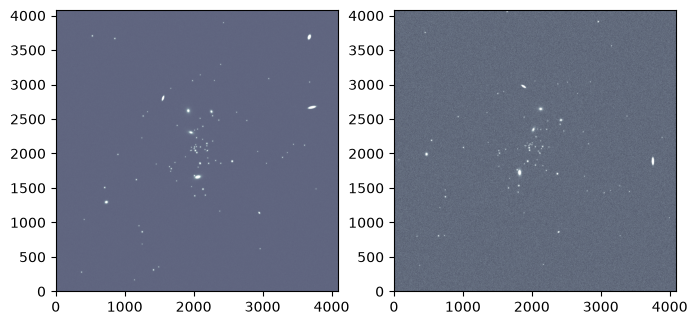

In [40]:
img_2 = fits.getdata(fits_file_2, ext=1)

fig_2, ax_2 = plt.subplots(1, 2, figsize=(8, 4))
ax_2[0].imshow(img_1, vmin=0.2, vmax=0.3, origin='lower', cmap='bone')
ax_2[1].imshow(img_2, vmin=0.2, vmax=0.3, origin='lower', cmap='bone')

### Add an Artifical Point Source to an Observation

With the STIPS `makePSF` utility, users can "clip" a PSF from a given detector pixel position in a scene and inject it elsewhere.

This is achieved by first applying a bi-linear interpolation of a 3x3 array from the STIPS PSF library to compute the best PSF at the specified integer SCA pixels, and then by performing bicubic interpolations over the PSF's supersampled pixel grid to fill out its sub-pixel positions. The resulting PSF can then be injected in an existing scene or used to create new scenes.

Use the `make_epsf_array()` method from STIPS' `AstroImage` class to create an example PSF from the library.

In [41]:
ai = AstroImage()

ai.detector = 'SCA01'
ai.filter = 'F129'
test_psf = ai.make_epsf_array()[0][0][0]

2026-09-06 02:46:14,349 INFO: WFI01: (RA, DEC, PA) := (0.0, 0.0, 0.0), detected as (0.0, 0.0, 0.0)


2026-09-06 02:46:14,355 INFO: PSF File psf_WFI_2.3.1_F129_sca01.fits to be put at /home/runner/psf_cache


2026-09-06 02:46:14,355 INFO: PSF File is /home/runner/psf_cache/psf_WFI_2.3.1_F129_sca01.fits


2026-09-06 02:46:14,548 INFO: WFI01: Starting 3x3 PSF Grid creation at Sun Sep  6 02:46:14 2026



Running instrument: WFI, filter: F129
  Running detector: WFI01
    Position 1/9: (0, 0) pixels


...

Attempted to get aberrations at field point (4095, 4095) which is outside the range of the reference data; approximating to nearest interpolated point (4095.004894881753, 4074.994618276213)


Attempted to get aberrations at field point (4095, 4095) which is outside the range of the reference data; approximating to nearest interpolated point (4095.004894881753, 4074.994618276213)


Attempted to get aberrations at field point (4095, 4095) which is outside the range of the reference data; approximating to nearest interpolated point (4095.004894881753, 4074.994618276213)


2026-09-06 02:46:54,297 INFO: WFI01: Finished PSF Grid creation at Sun Sep  6 02:46:54 2026


    Position 9/9 centroid: (np.float64(87.63467976133113), np.float64(88.31165394312333))
  Saving file: /home/runner/psf_cache/psf_WFI_2.3.1_F129_wfi01.fits


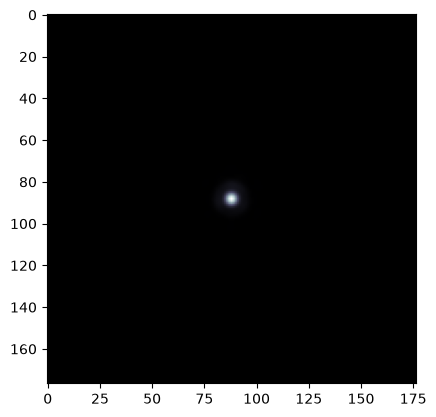

In [42]:
plt.imshow(test_psf, cmap='bone')

Specify the pixel coordinates of the source's center (which are just the center of the PSF in this case) and the pixel length of the intended cutout (1/8th of the full example PSF's pixel length).

In [43]:
psf_mid_pixel = (test_psf.shape[0] - 1) // 2
boxsize = test_psf.shape[0] // 8

Inject the source at pixel (2000, 2000) with an arbitrary flux of 3000 DN/sec in a copy of the simulated image from the second observation simulated above. Can you see the newly injected PSF in the comparison plot?

In [44]:
img_3 = img_2.copy()
xpix = 2000
ypix = 2000
flux = 3000

img_3_inj = stips.utilities.makePSF.place_source(xpix, ypix, flux, img_3,
                                                 test_psf, boxsize=boxsize,
                                                 psf_center=psf_mid_pixel)

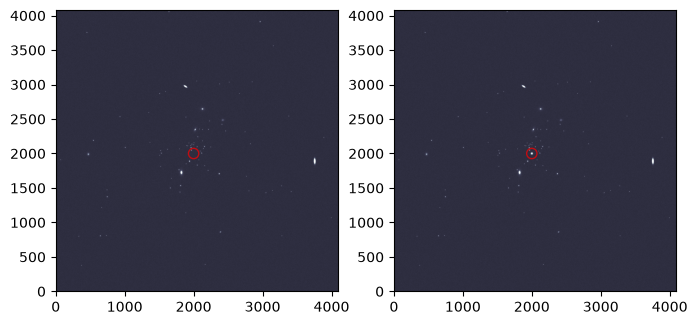

In [45]:
fig_3, ax_3 = plt.subplots(1, 2, figsize=(8, 4))
ax_3[0].imshow(img_2, vmin=0.15, vmax=0.6, origin='lower', cmap='bone')
ax_3[1].imshow(img_3_inj, vmin=0.15, vmax=0.6, origin='lower', cmap='bone')

for ax in ax_3:
    ax.add_patch(plt.Circle((xpix, ypix), 75, color='r', alpha=.7, fill=False))

## Additional Resources

- The Roman User Documentation's ["STIPS Overview"](https://roman-docs.stsci.edu/simulation-tools-handbook-home/stips-space-telescope-imaging-product-simulator/overview-of-stips) page and associated tutorials.
- The latest version of the [STIPS documentation](https://stips.readthedocs.io/en/latest/) on ReadTheDocs.
- The [Roman Help Desk](https://roman-docs.stsci.edu/roman-help-desk-at-stsci), an official outlet for user questions about STIPS.

***

## About this Notebook

**Author:** Justin Otor, Eunkyu Han  
**Updated On:** 2025-01-08

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>